## Setup

In [66]:
import json

import matplotlib.pyplot as plt
import pandas as pd

In [67]:
pd.set_option('display.max_columns', 150)
plt.style.use('ggplot')

In [ ]:
results_older = 'results/ram_benchmark_20250926_103509.jsonl'
results_new = 'results/ram_benchmark_20250926_143804.jsonl'

In [16]:

def load_results_file(fpath):
    data = []
    with open(fpath, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data


## Data

In [18]:
data_older = load_results_file(results_older)
df_older = pd.DataFrame(data_older)

In [28]:
df_older.head(3)

,timestamp,test_type,test_size_mb,test_pattern,iteration,total_memory_kb,available_memory_kb,memory_clock_info,write_time_seconds,write_speed_mb_per_sec,read_time_seconds,read_speed_mb_per_sec,random_read_time_seconds,random_read_speed_mb_per_sec,bandwidth_time_seconds,bandwidth_speed_mb_per_sec,avg_latency_seconds,median_latency_seconds,block_size,operation,access_mode,threads,memory_total_size,sysbench_total_time_seconds,sysbench_transferred_mb,sysbench_operations,sysbench_latency_avg_ms,sysbench_latency_min_ms,sysbench_latency_max_ms,sysbench_latency_95th_ms,sysbench_throughput_mb_per_sec
0,2025-09-26T10:35:09-03:00,memory,100,sequential,1,16182700,14536572,2667MHz,0.031552,3169.40,0.012724,7859.30,0.101705,983.23,0.114258,1750.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-26T10:35:09-03:00,memory,100,sequential,2,16182700,14536572,2667MHz,0.035103,2848.76,0.011486,8705.92,0.118931,840.82,0.173989,1149.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-26T10:35:09-03:00,memory,100,sequential,3,16182700,14536572,2667MHz,0.035194,2841.35,0.011583,8633.17,0.212674,470.20,0.176084,1135.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
data_new = load_results_file(results_new)
df_new = pd.DataFrame(data_new)

In [29]:
df_new.head(3)

,timestamp,test_type,test_size_mb,test_pattern,iteration,total_memory_kb,available_memory_kb,memory_clock_info,write_time_seconds,write_speed_mb_per_sec,read_time_seconds,read_speed_mb_per_sec,random_read_time_seconds,random_read_speed_mb_per_sec,bandwidth_time_seconds,bandwidth_speed_mb_per_sec,avg_latency_seconds,median_latency_seconds,block_size,operation,access_mode,threads,memory_total_size,sysbench_total_time_seconds,sysbench_transferred_mb,sysbench_operations,sysbench_latency_avg_ms,sysbench_latency_min_ms,sysbench_latency_max_ms,sysbench_latency_95th_ms,sysbench_throughput_mb_per_sec
0,2025-09-26T14:38:04-03:00,memory,100,sequential,1,16182704,14546264,3200MHz,0.033565,2979.27,0.012655,7902.30,0.087829,1138.58,0.118257,1691.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-26T14:38:04-03:00,memory,100,sequential,2,16182704,14546264,3200MHz,0.036764,2720.07,0.011720,8532.65,0.120582,829.31,0.158439,1262.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-26T14:38:04-03:00,memory,100,sequential,3,16182704,14546264,3200MHz,0.065430,1528.35,0.011766,8499.02,0.185495,539.09,0.129597,1543.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df_all = pd.concat([df_older, df_new], ignore_index=True)

## Analy

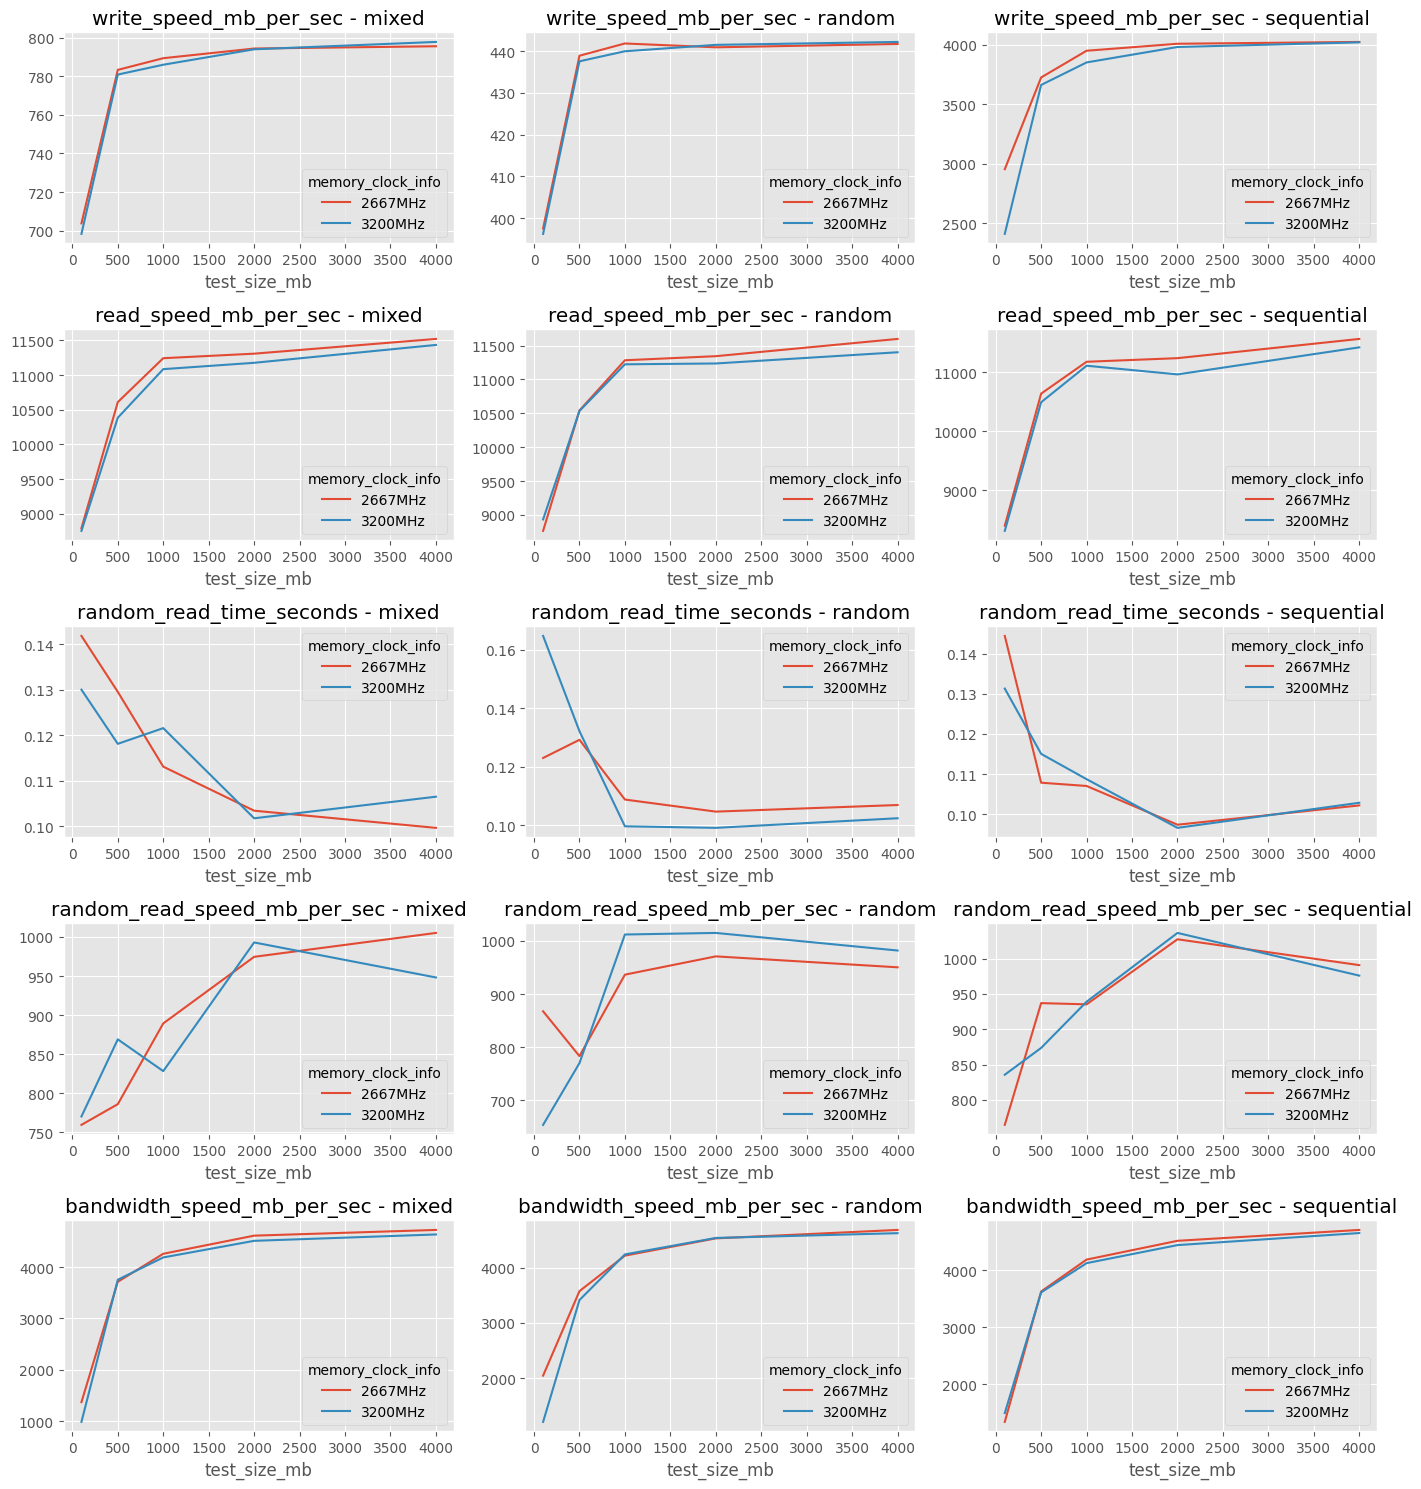

In [106]:
mem_df = df_all.loc[df_all['test_type'] == 'memory'].copy()
mem_df.dropna(axis='columns', how='all', inplace=True)
dimensions_cols = ['memory_clock_info', 'test_pattern', 'test_size_mb']
metrics_cols = ['write_speed_mb_per_sec', 'read_speed_mb_per_sec', 'random_read_time_seconds', 'random_read_speed_mb_per_sec', 'bandwidth_speed_mb_per_sec']
mem_df = mem_df.groupby(dimensions_cols, as_index=False)[metrics_cols].mean()

rows_num = len(metrics_cols)
cols_num = len(mem_df['test_pattern'].unique())
fig, axs = plt.subplots(ncols=cols_num, nrows=rows_num, figsize=(14, 3*rows_num))
axs_flat = axs.flat
ind = 0
for mtrc in metrics_cols:
    for pttn in mem_df['test_pattern'].unique():
        pivot_df = mem_df.loc[mem_df['test_pattern'] == pttn].pivot(index='test_size_mb', columns='memory_clock_info', values=mtrc)
        pivot_df.plot(title=f"{mtrc} - {pttn}", ax=axs_flat[ind])
        ind += 1
plt.tight_layout()
plt.show()

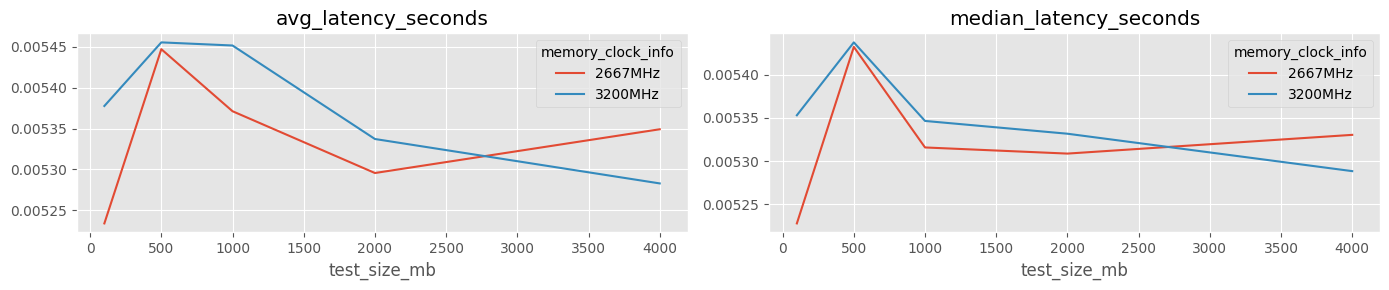

In [97]:
lat_df = df_all.loc[df_all['test_type'] == 'latency'].copy()
lat_df.dropna(axis='columns', how='all', inplace=True)
dimensions_cols = ['memory_clock_info', 'test_size_mb']
metrics_cols = ['avg_latency_seconds', 'median_latency_seconds']
lat_df = lat_df.groupby(dimensions_cols, as_index=False)[metrics_cols].mean()

rows_num = 1
cols_num = len(metrics_cols)
fig, axs = plt.subplots(ncols=cols_num, nrows=rows_num, figsize=(14, 3*rows_num))
axs_flat = axs.flat
ind = 0
for mtrc in metrics_cols:
    pivot_df = lat_df.pivot(index='test_size_mb', columns='memory_clock_info', values=mtrc)
    pivot_df.plot(title=f"{mtrc}", ax=axs_flat[ind])
    ind += 1
plt.tight_layout()
plt.show()

sysbench_total_time_seconds  ###################################
block_size  ----------------------------------


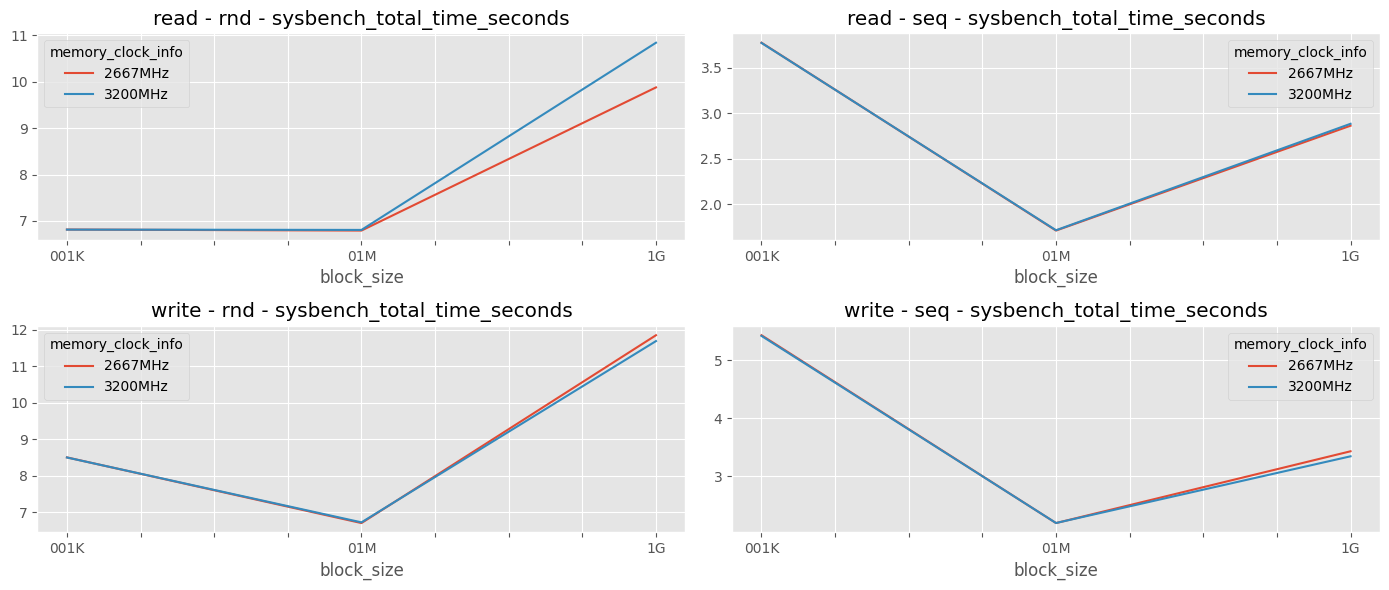


test_size_mb  ----------------------------------


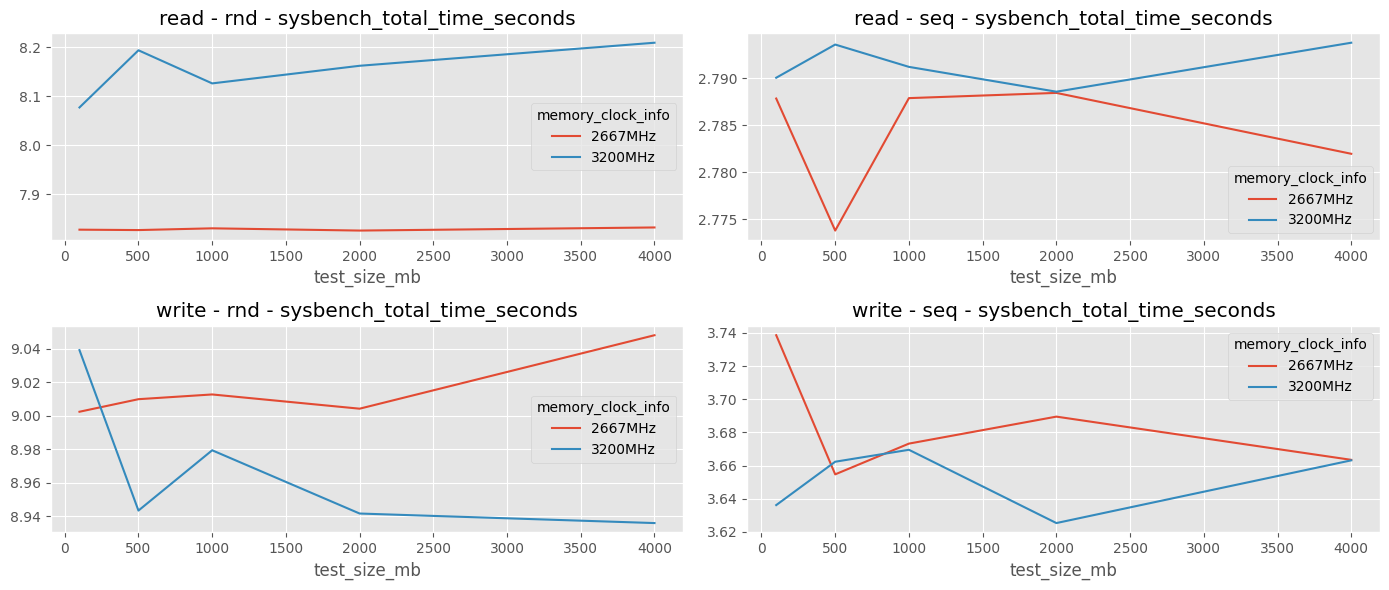


memory_total_size  ----------------------------------


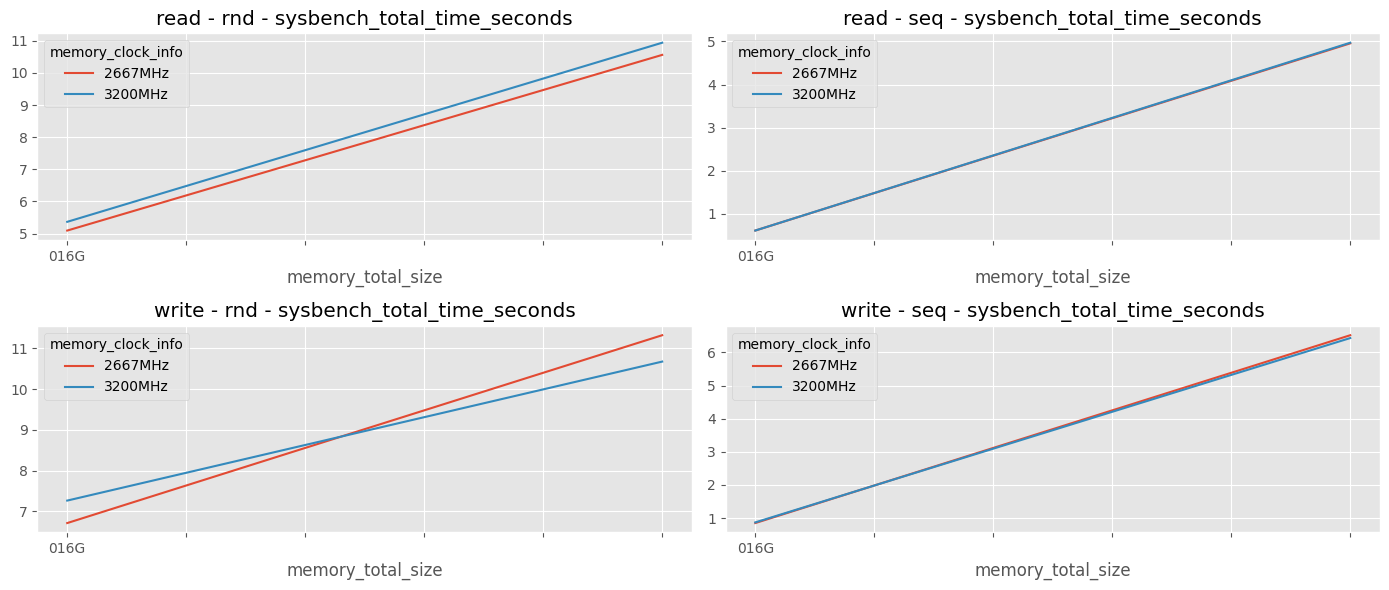


threads  ----------------------------------


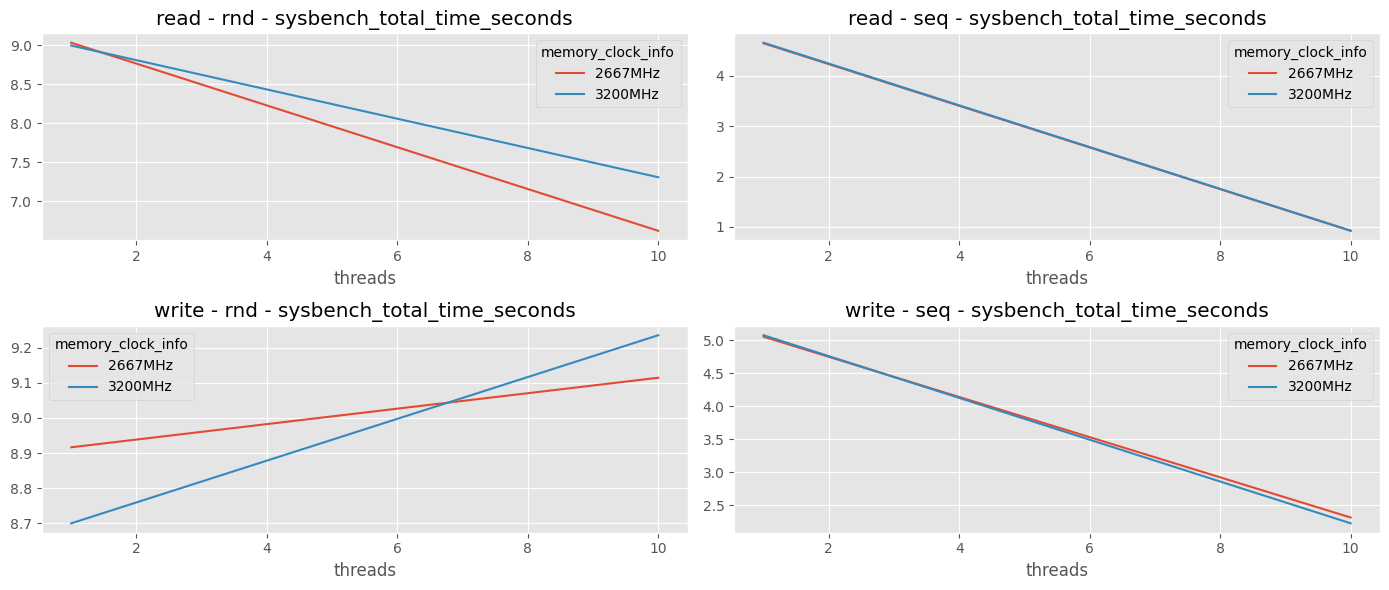


sysbench_transferred_mb  ###################################
block_size  ----------------------------------


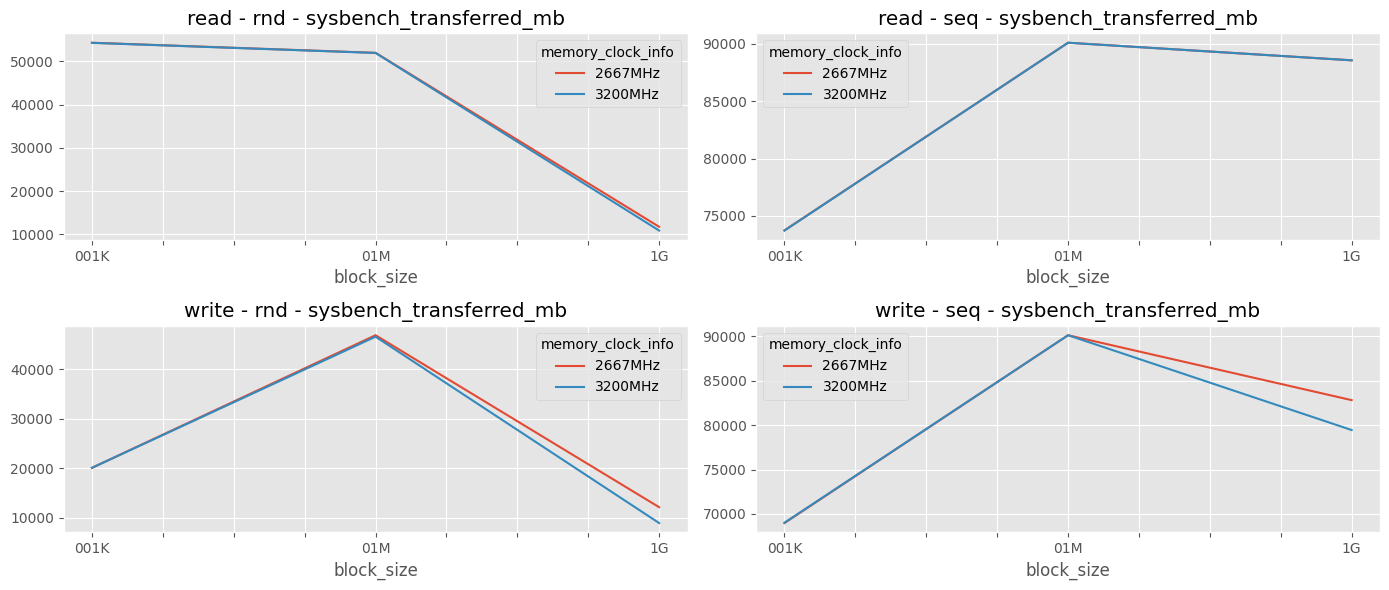


test_size_mb  ----------------------------------


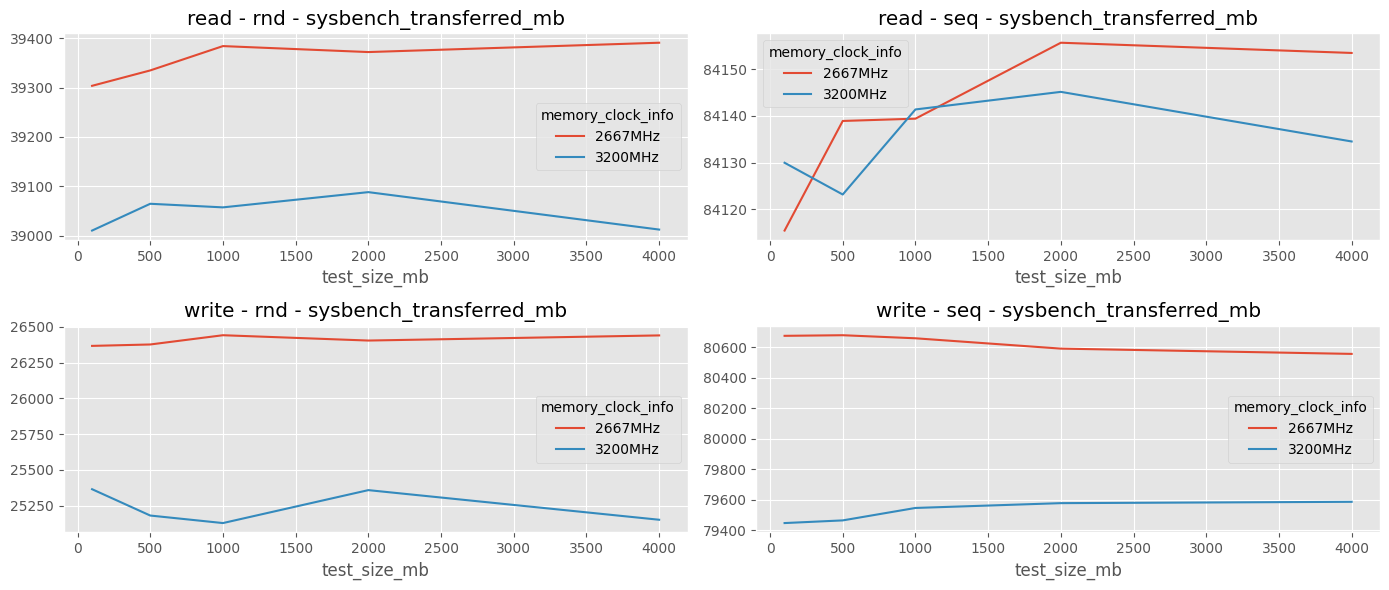


memory_total_size  ----------------------------------


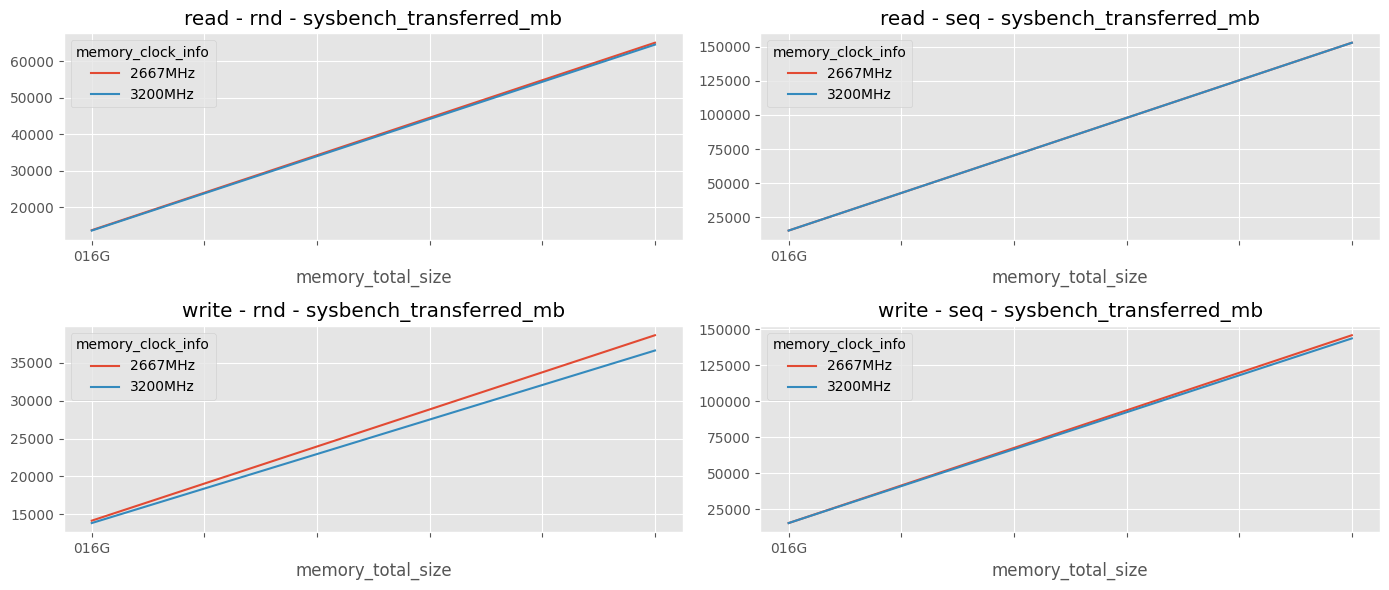


threads  ----------------------------------


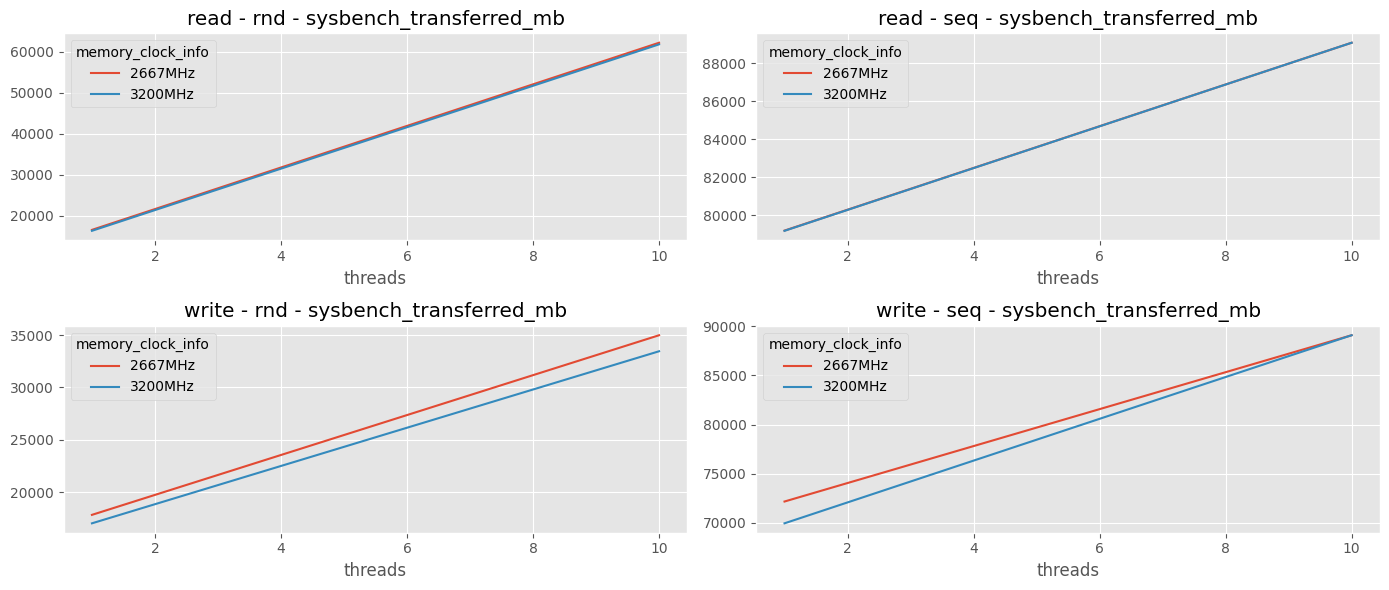


sysbench_latency_avg_ms  ###################################
block_size  ----------------------------------


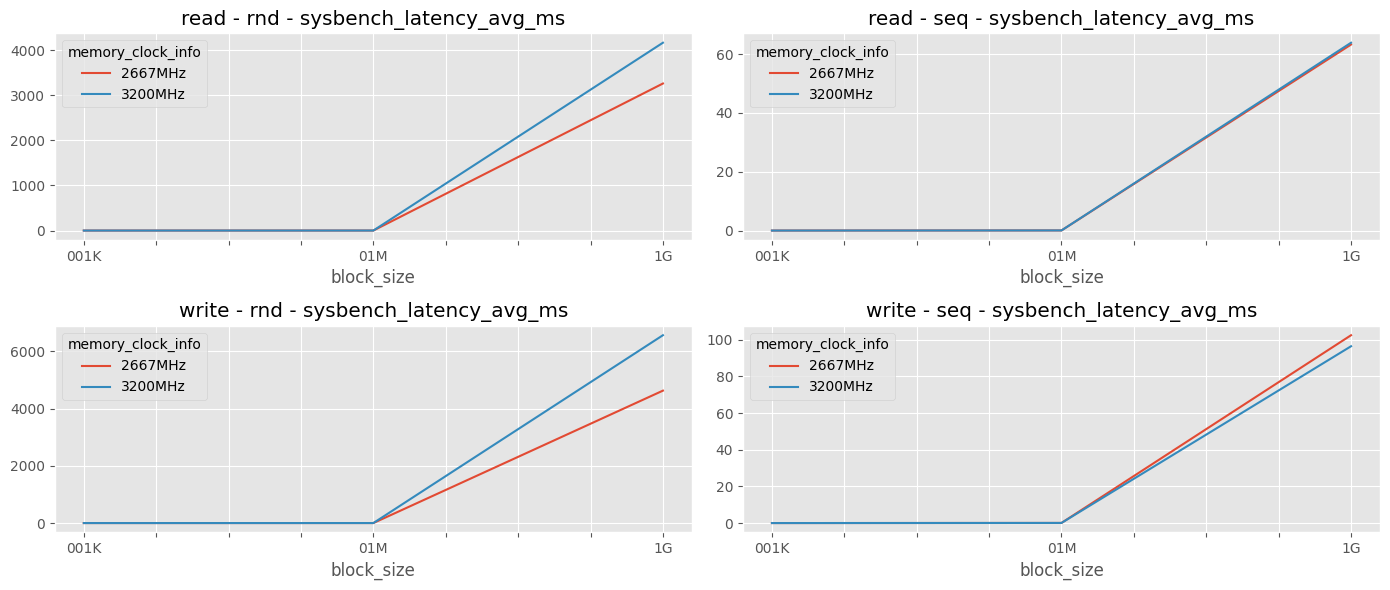


test_size_mb  ----------------------------------


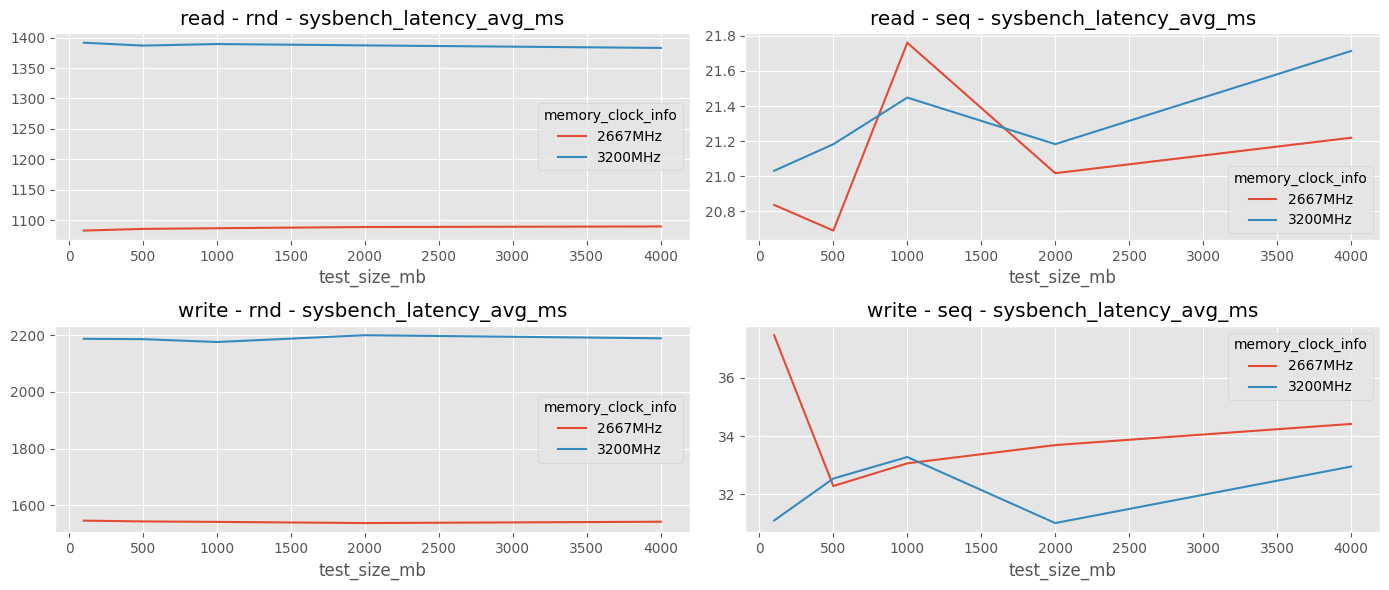


memory_total_size  ----------------------------------


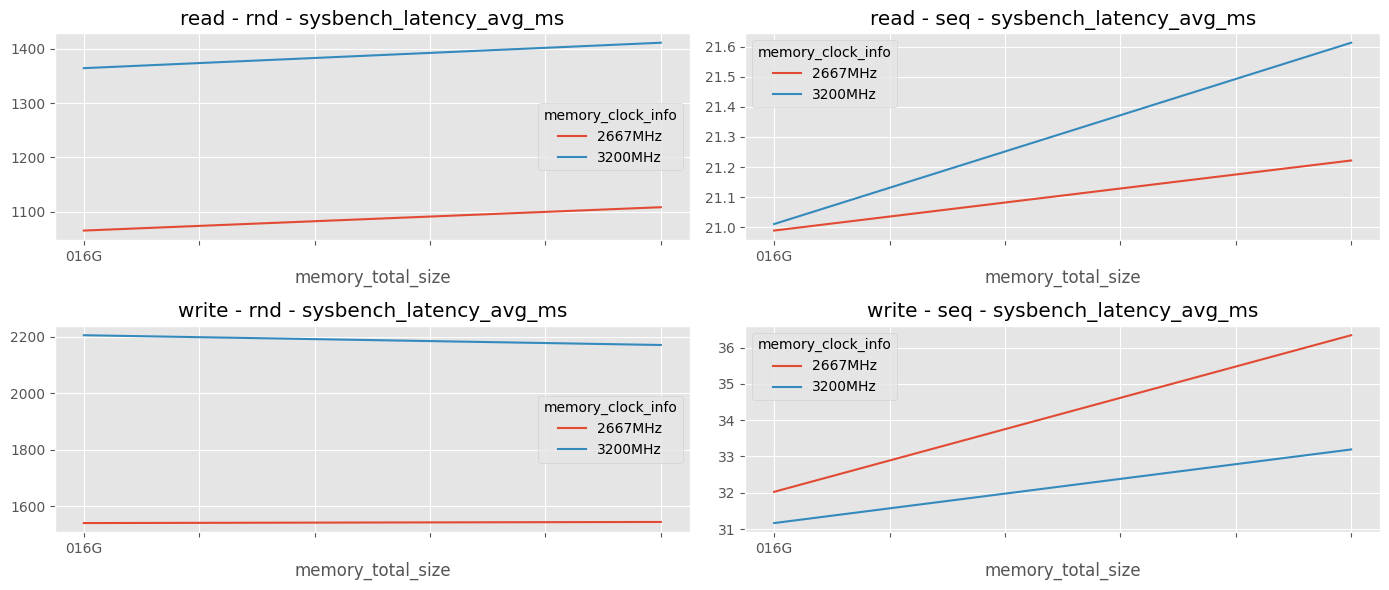


threads  ----------------------------------


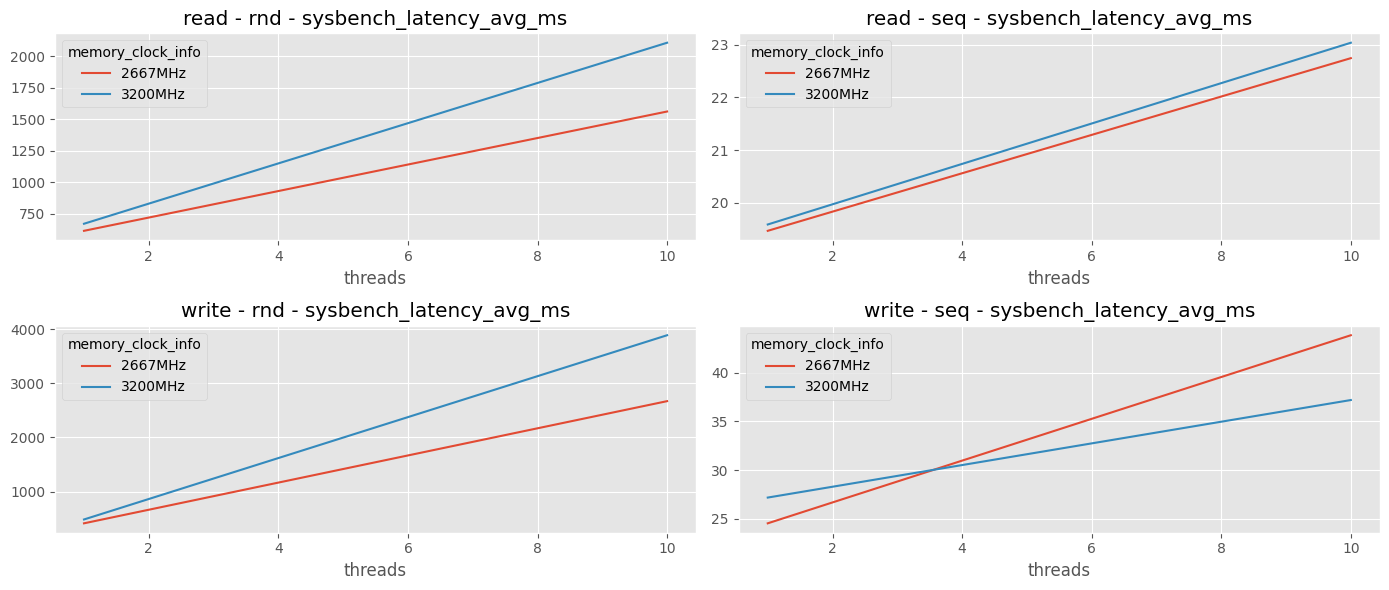


sysbench_latency_min_ms  ###################################
block_size  ----------------------------------


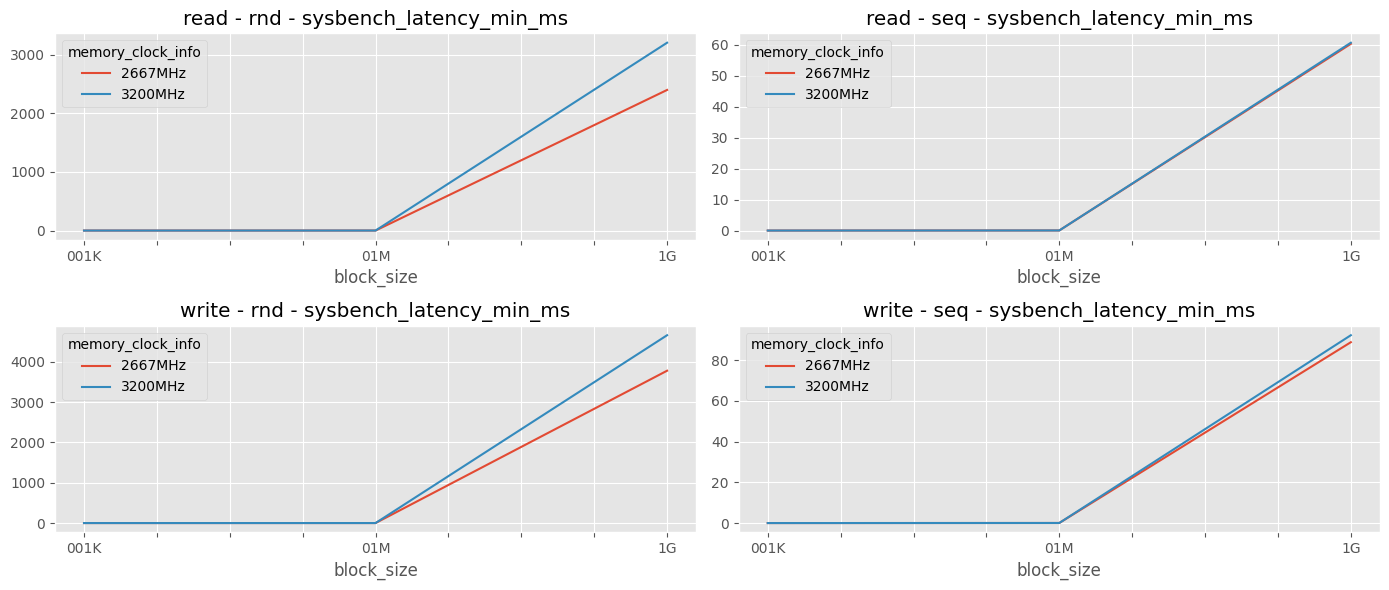


test_size_mb  ----------------------------------


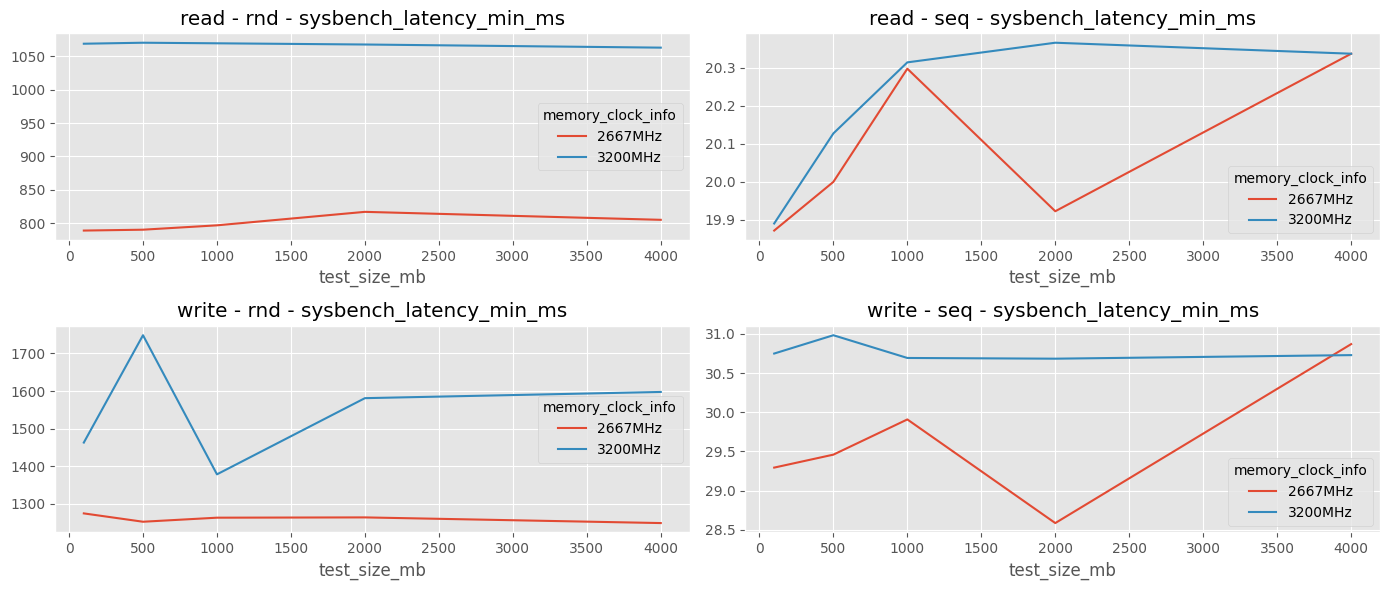


memory_total_size  ----------------------------------


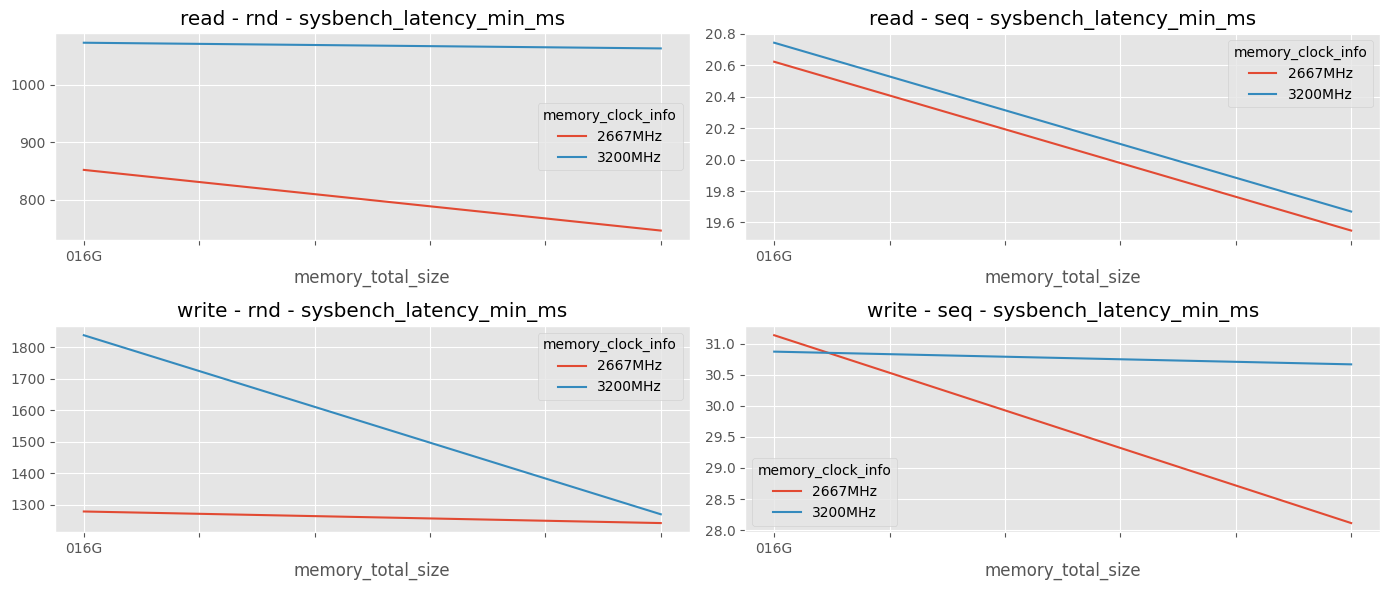


threads  ----------------------------------


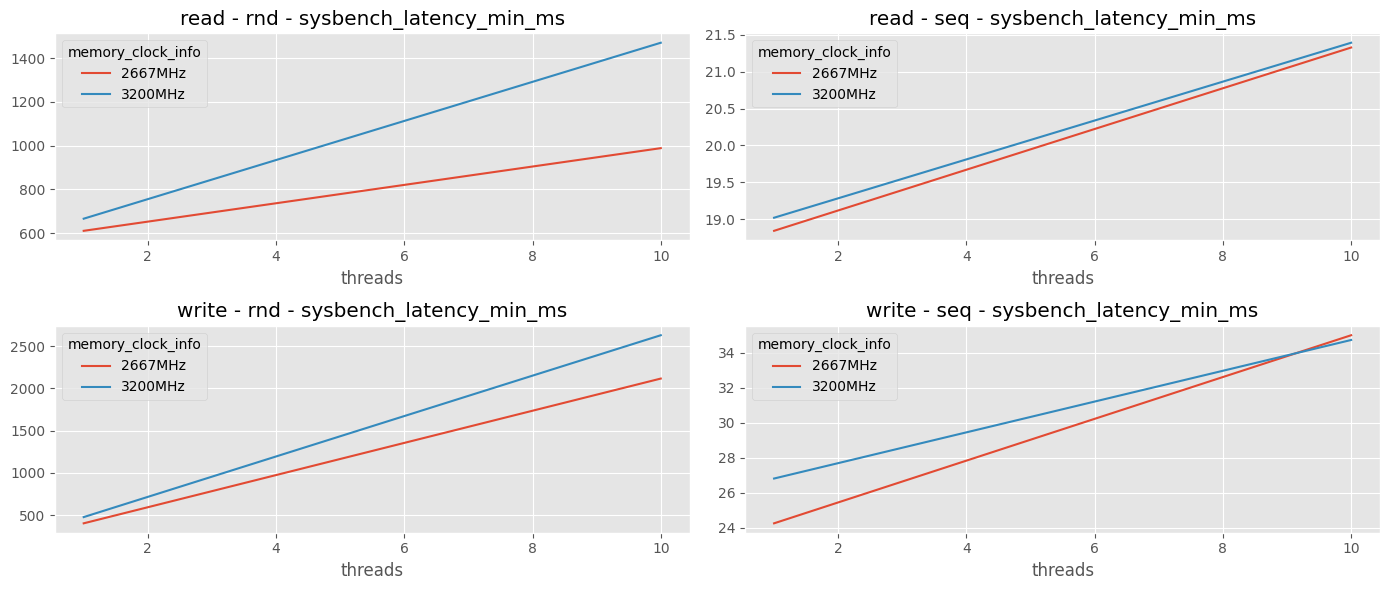


sysbench_latency_max_ms  ###################################
block_size  ----------------------------------


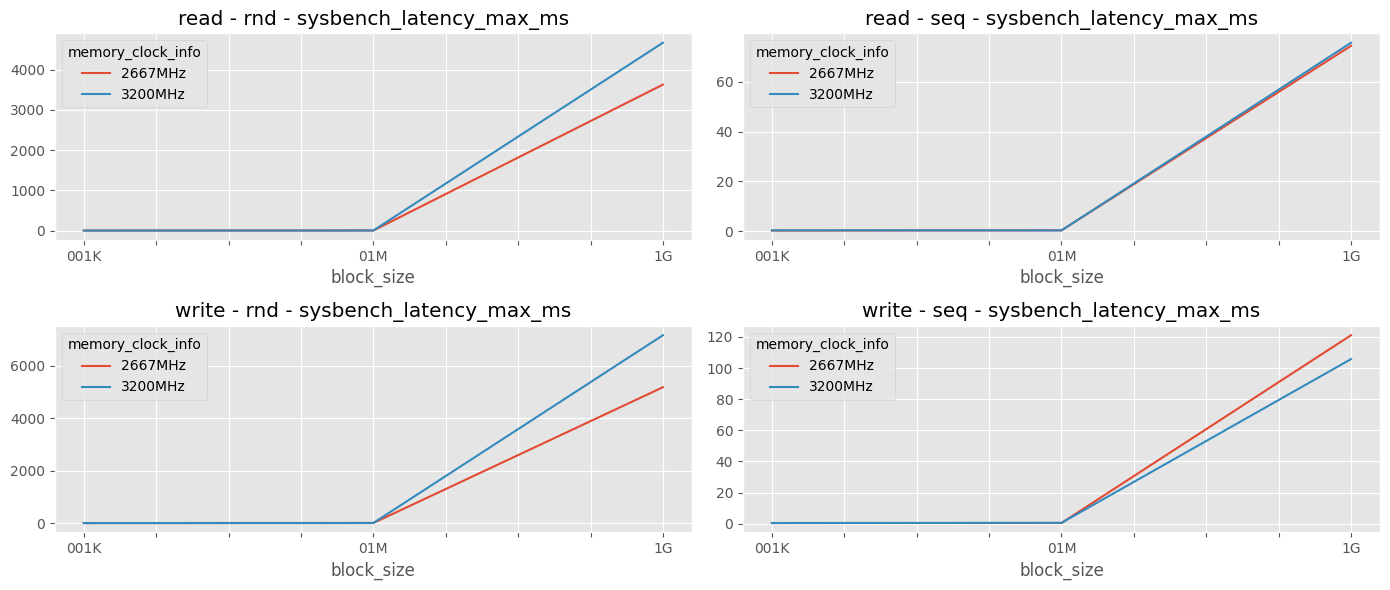


test_size_mb  ----------------------------------


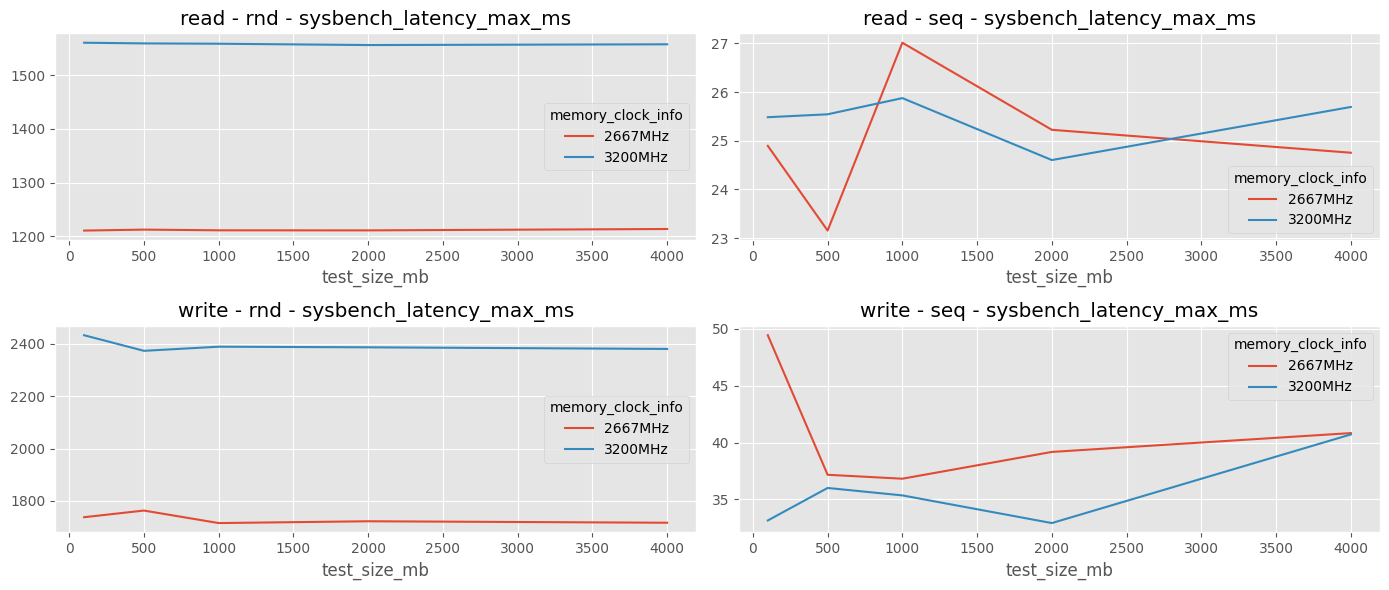


memory_total_size  ----------------------------------


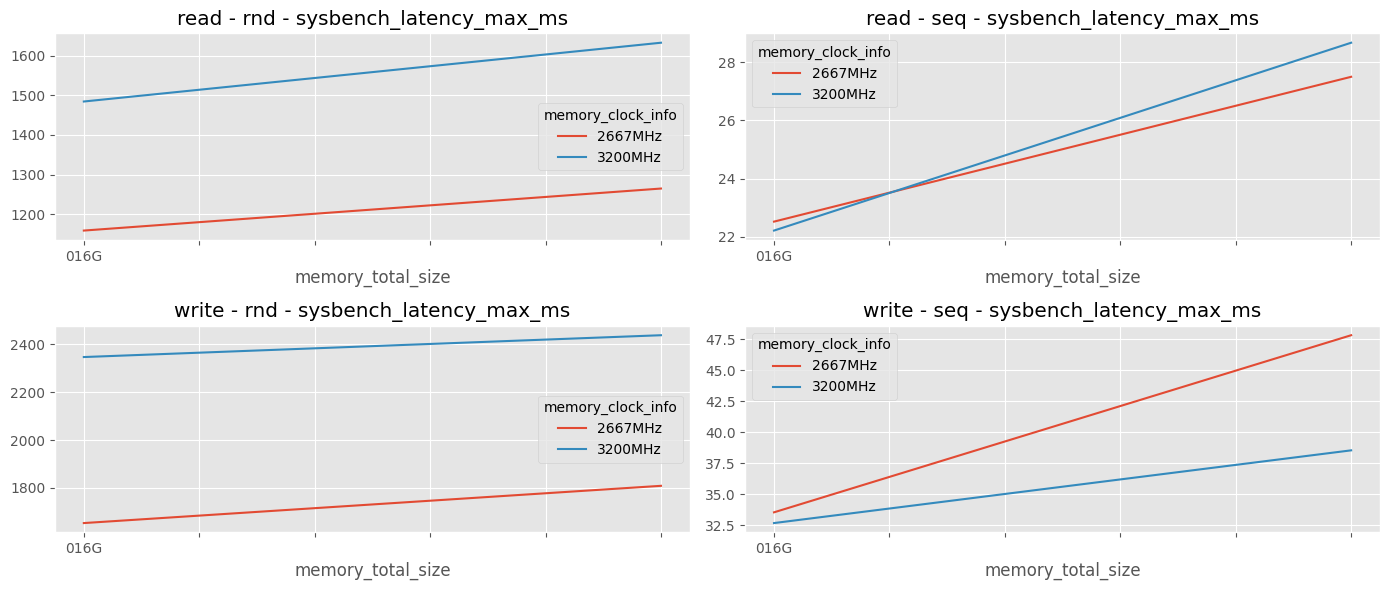


threads  ----------------------------------


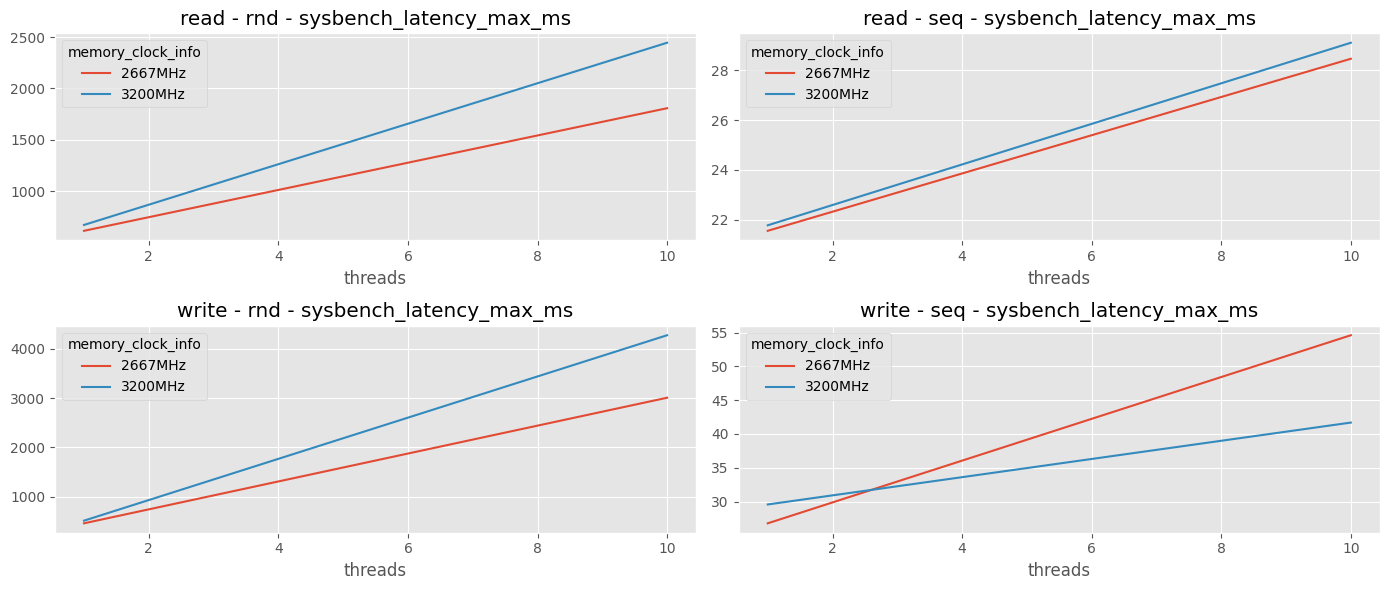


sysbench_latency_95th_ms  ###################################
block_size  ----------------------------------


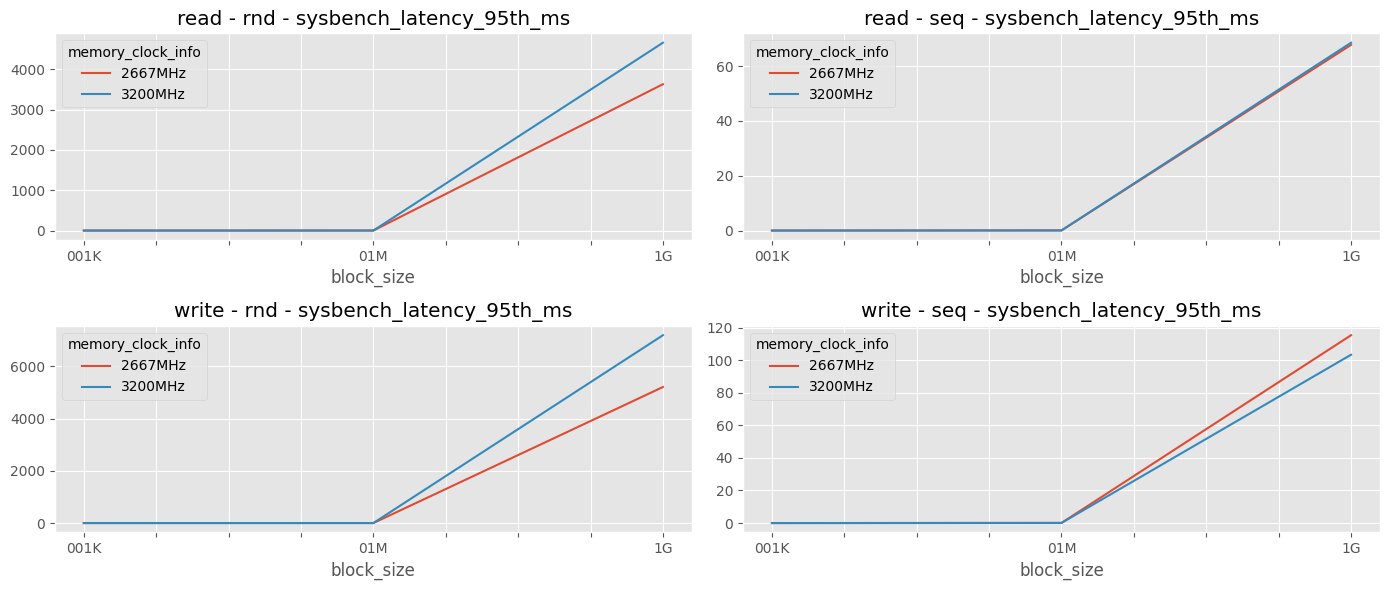


test_size_mb  ----------------------------------


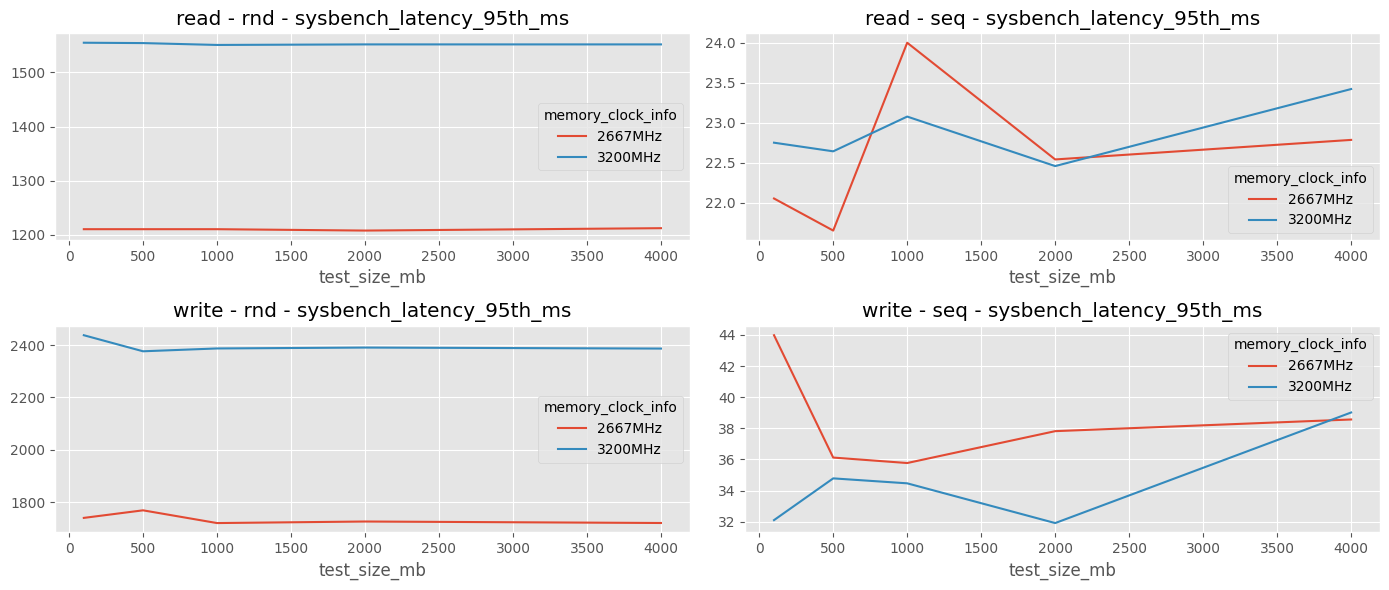


memory_total_size  ----------------------------------


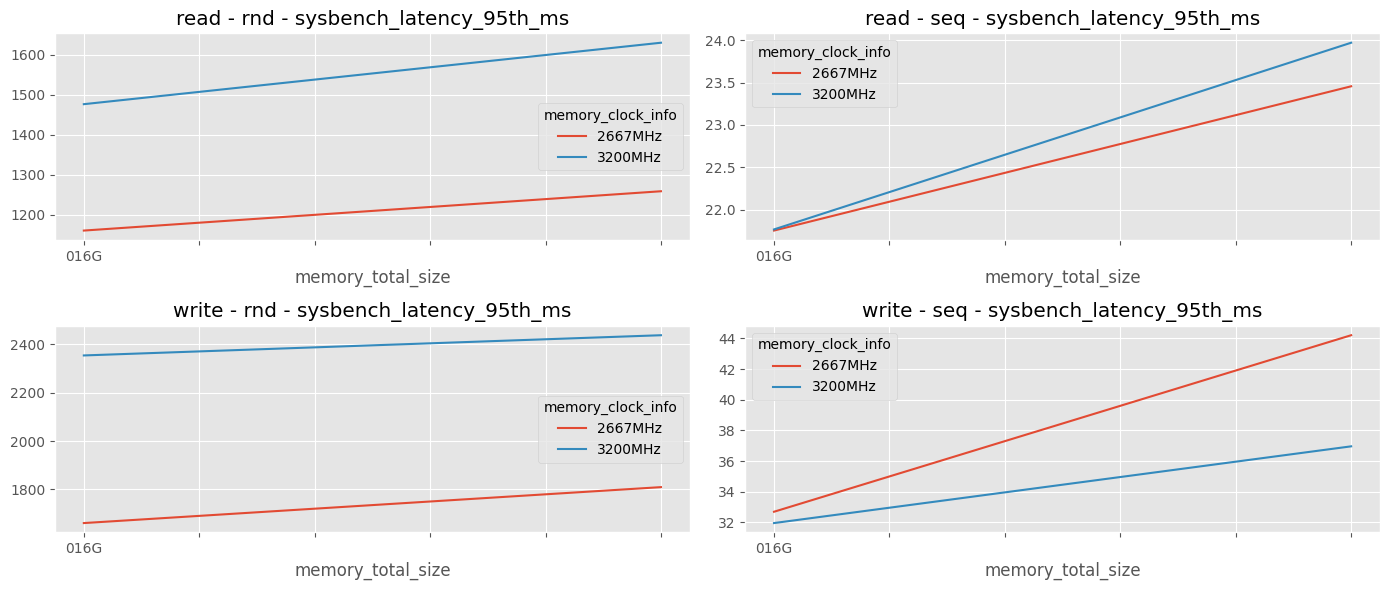


threads  ----------------------------------


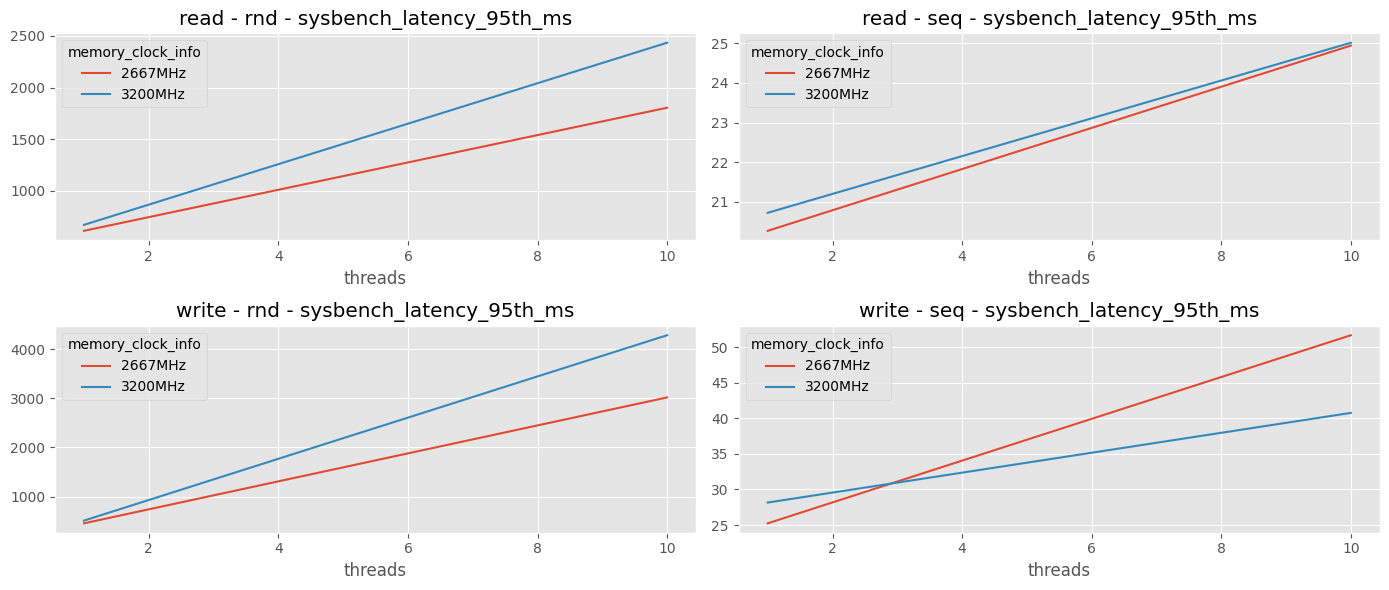


sysbench_throughput_mb_per_sec  ###################################
block_size  ----------------------------------


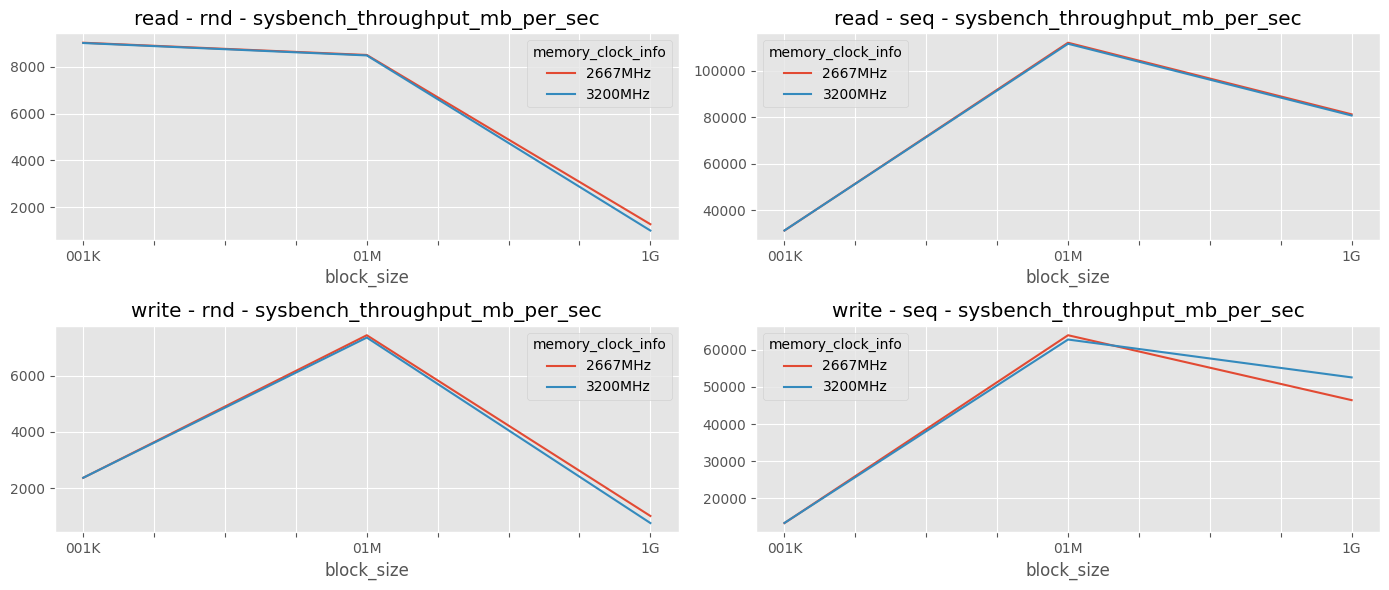


test_size_mb  ----------------------------------


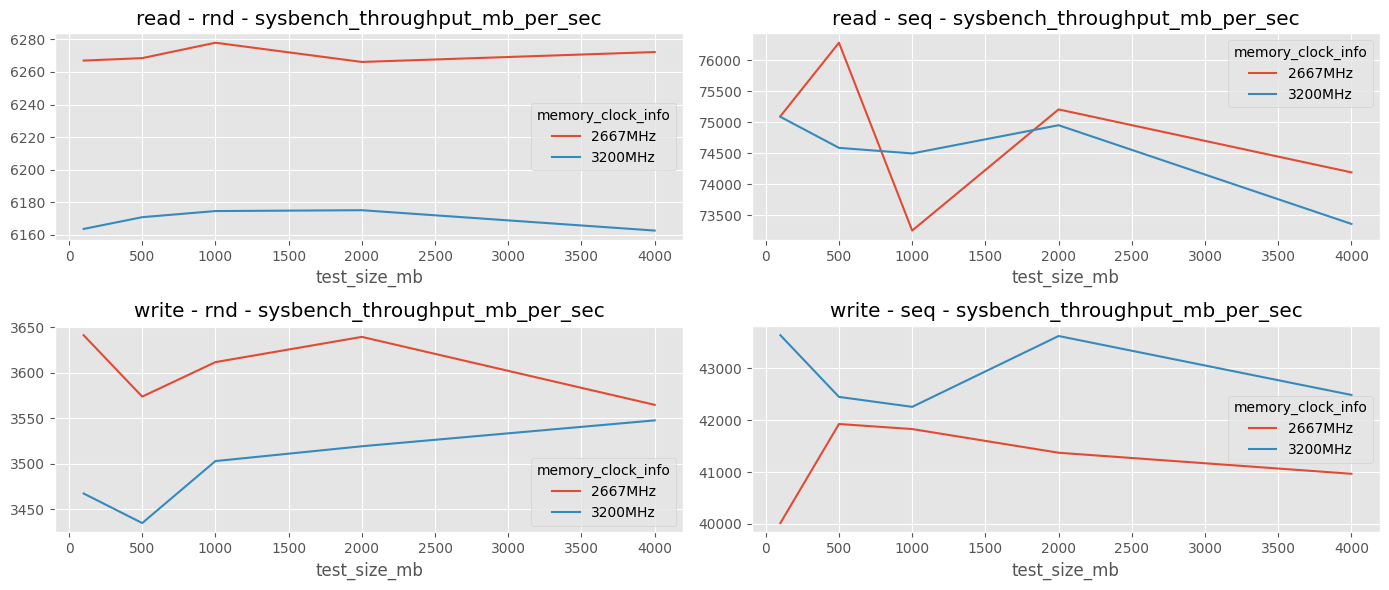


memory_total_size  ----------------------------------


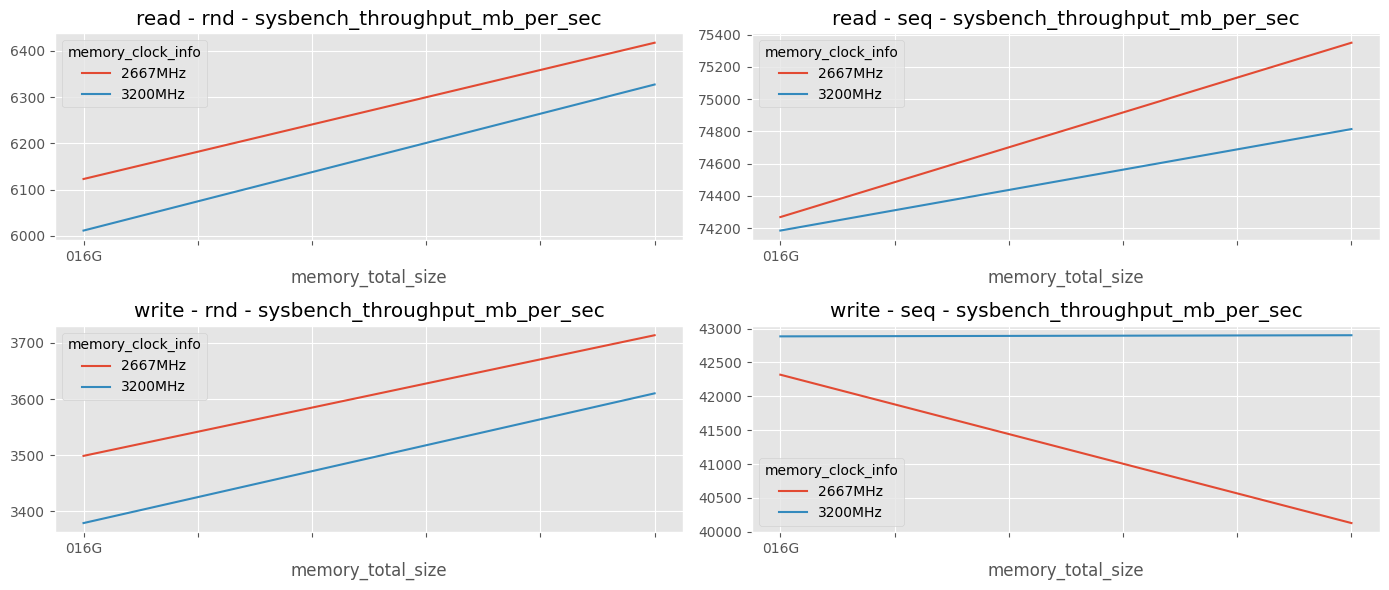


threads  ----------------------------------


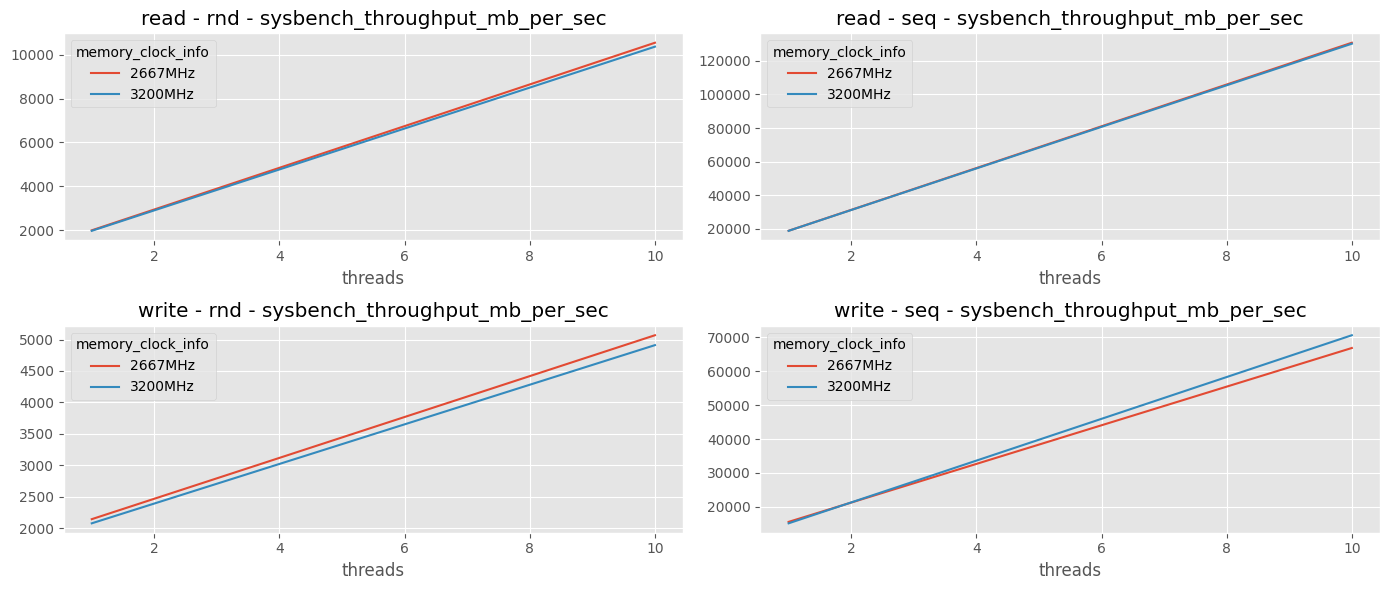

In [153]:
sys_df = df_all.loc[df_all['test_type'] == 'sysbench'].copy()
sys_df.dropna(axis='columns', how='all', inplace=True)
remap_cols = ['block_size', 'memory_total_size', ]
vars_map = {'16G': '016G', '1K': '001K', '1M': '01M'}
for col in remap_cols:
    vmap = {v: v for v in sys_df[col].unique()}
    vmap.update(vars_map)
    sys_df[col] = sys_df[col].map(vmap)
dimensions_cols = ['memory_clock_info', 'operation', 'access_mode', 'block_size', 'test_size_mb', 'memory_total_size', 'threads']
metrics_cols = ['sysbench_total_time_seconds', 'sysbench_transferred_mb', 'sysbench_latency_avg_ms', 'sysbench_latency_min_ms', 'sysbench_latency_max_ms', 'sysbench_latency_95th_ms', 'sysbench_throughput_mb_per_sec']
sys_df = sys_df.groupby(dimensions_cols, as_index=False)[metrics_cols].mean()

for mtrc in metrics_cols:
    print(f'{mtrc}  ###################################')
    for dim in dimensions_cols:
        if dim in ['block_size', 'test_size_mb', 'memory_total_size', 'threads']:
            print(f'{dim}  ----------------------------------')
            rows_vars = sys_df['operation'].unique()
            cols_vars = sys_df['access_mode'].unique()
            rows_num = len(rows_vars)
            cols_num = len(cols_vars)
            fig, axs = plt.subplots(ncols=cols_num, nrows=rows_num, figsize=(14, 3*rows_num))
            for ind0, row in enumerate(rows_vars):
                for ind1, col in enumerate(cols_vars):
                    tmp_df = sys_df.loc[(sys_df['operation'] == row) & (sys_df['access_mode'] == col)].groupby([dim, 'memory_clock_info'], as_index=False)[mtrc].mean()
                    pivot_df = tmp_df.pivot(index=dim, columns='memory_clock_info', values=mtrc)
                    pivot_df.plot(title=f"{row} - {col} - {mtrc}", ax=axs[ind0, ind1])
            plt.tight_layout()
            plt.show()
            print()